Note: readthedocs will not be able to run copilot. Need to find a way to not run but save outputs.

In [12]:
model = "claude-sonnet-4.5"
model = "gpt-5"

<!-- Display image from web -->
<img src="https://raw.githubusercontent.com/zczlsde/GameInterpreter/main/Image/Full_Pipeline.png" alt="Full Pipeline" width="75%">

In [ ]:
from IPython.display import Markdown, display

In [ ]:
# Function to load game descriptions and prompts from GitHub repository
import urllib.request
import json
from urllib.parse import quote

def get_descriptions(folder):
    api_url = "https://api.github.com/repos/zczlsde/GameInterpreter/contents/" + folder
    url_base = "https://raw.githubusercontent.com/zczlsde/GameInterpreter/main/" + folder + "/"

    # Use GitHub API to list files in the directory
    with urllib.request.urlopen(api_url) as response:
        files_info = json.loads(response.read().decode('utf-8'))

    # Get list of .txt files
    txt_files = [f['name'] for f in files_info if f['name'].endswith('.txt')]

    print(f"Found {len(txt_files)} text files in {folder}:")
    print(txt_files)

    # Load descriptions
    descriptions = {}
    for filename in txt_files:
        with urllib.request.urlopen(url_base + quote(filename)) as response:
            descriptions[filename] = response.read().decode('utf-8')
    return descriptions

In [34]:
prompts = get_descriptions("Prompts")

Found 5 text files in Prompts:
['Code_Generation_Initialization.txt', 'EFG_Generation.txt', 'Error_Message.txt', 'Imperfect_Information_Retrieval.txt', 'Imperfect_Information_Retrieval_Initialization.txt']


In [35]:
prompts["Code_Generation_Initialization.txt"]

'Given a game description in natural language, you will be asked to generate python code for the Gambit API (pygambit) to construct a corresponding extensive-form game in Gambit. \nHere are two examples of how to use pygambit library:\n\nExample 1:\nGame description:\nThere are two players, a Buyer and a Seller. The Buyer moves first and has two actions, Trust or Not trust. If the Buyer chooses Not trust, then the game ends, and both players receive payoffs of 0. If the Buyer chooses Trust, then the Seller has a choice with two actions, Honor or Abuse. If the Seller chooses Honor, both players receive payoffs of 1; if the Seller chooses Abuse, the Buyer receives a payoff of -1 and the Seller receives a payoff of 2.\nCode:\n```python\nimport pygambit as gbt\ng = gbt.Game.new_tree(players=["Buyer", "Seller"],\n                    title="One-shot trust game, after Kreps (1990)")\n\ng.append_move(g.root, "Buyer", ["Trust", "Not trust"])\ng.append_move(g.root.children[0], "Seller", ["Honor"

In [33]:
perfect_information_games = get_descriptions("Dataset/Perfect%20Information%20Games")

Found 6 text files in Dataset/Perfect%20Information%20Games:
['Centipede.txt', 'Colonial_Control.txt', 'Market_Entry_Model.txt', 'Nim_(with_five_in_one_pile).txt', 'Simple_Bargaining_Game.txt', 'Tic-Tac-Toe.txt']


In [43]:
display(Markdown(perfect_information_games["Centipede.txt"]))

Consider a game with two players, Alice and Bob, where Alice makes the first move. At the start, Alice has two piles of coins in front of her: one pile with 4 coins and another with 1 coin. Each player has two options on their turn: they can either take the larger pile, giving the smaller pile to the other player, or they can push both piles to the other player. Whenever the piles are pushed across the table, the number of coins in each pile doubles. For instance, if Alice chooses to push on her first turn, the piles of 1 and 4 coins are handed over to Bob, increasing to 2 and 8 coins. Bob can then decide either to take the pile of 8 coins and leave 2 for Alice or to push the piles back to Alice, further doubling them to 4 and 16 coins (The last push will not double the coin). If neither player takes the coins by the end of the game, Alice will receive the pile with the higher value, and Bob will get the one with the lower value. 
The game has four moves in total: Alice moves (take or push), Bob moves (take or push, where the final push also doubles the piles before the game ends), Alice moves again, and finally, Bob moves. All actions are visible to both players.

In [17]:
import subprocess

def call_copilot(model, prompt):
    cmd = f"copilot --model {model} -p '{prompt}'"
    proc = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if proc.stdout:
        return proc.stdout
    else:
        # Return error message if no output
        print("STDERR:", proc.stderr)
        print("Return code:", proc.returncode)

In [36]:
response = call_copilot("gpt-5",
             prompts["Code_Generation_Initialization.txt"] + "\n\n" +
             perfect_information_games["Centipede.txt"]
             )
response

'Assumption: every push, including the final one, doubles the piles before the game ends.\n\n```python\nimport pygambit as gbt\ng = gbt.Game.new_tree(players=["Alice", "Bob"], title="Four-move doubling coin push game")\n\n# Move 1: Alice\ng.append_move(g.root, "Alice", ["Take", "Push"])\ng.set_outcome(g.root.children[0], g.add_outcome([4, 1], label="Alice takes 4, Bob 1"))  # End\n\n# After Alice pushes: piles double to (2, 8); Move 2: Bob\ng.append_move(g.root.children[1], "Bob", ["Take", "Push"])\ng.set_outcome(g.root.children[1].children[0], g.add_outcome([2, 8], label="Bob takes 8, Alice 2"))  # End\n\n# After Bob pushes: piles double to (4, 16); Move 3: Alice\ng.append_move(g.root.children[1].children[1], "Alice", ["Take", "Push"])\ng.set_outcome(g.root.children[1].children[1].children[0], g.add_outcome([16, 4], label="Alice takes 16, Bob 4"))  # End\n\n# After Alice pushes: piles double to (8, 32); Move 4: Bob\ng.append_move(g.root.children[1].children[1].children[1], "Bob", ["Ta

In [ ]:
display(Markdown(response))

Assumption: every push, including the final one, doubles the piles before the game ends.

```python
import pygambit as gbt
g = gbt.Game.new_tree(players=["Alice", "Bob"], title="Four-move doubling coin push game")

# Move 1: Alice
g.append_move(g.root, "Alice", ["Take", "Push"])
g.set_outcome(g.root.children[0], g.add_outcome([4, 1], label="Alice takes 4, Bob 1"))  # End

# After Alice pushes: piles double to (2, 8); Move 2: Bob
g.append_move(g.root.children[1], "Bob", ["Take", "Push"])
g.set_outcome(g.root.children[1].children[0], g.add_outcome([2, 8], label="Bob takes 8, Alice 2"))  # End

# After Bob pushes: piles double to (4, 16); Move 3: Alice
g.append_move(g.root.children[1].children[1], "Alice", ["Take", "Push"])
g.set_outcome(g.root.children[1].children[1].children[0], g.add_outcome([16, 4], label="Alice takes 16, Bob 4"))  # End

# After Alice pushes: piles double to (8, 32); Move 4: Bob
g.append_move(g.root.children[1].children[1].children[1], "Bob", ["Take", "Push"])
g.set_outcome(g.root.children[1].children[1].children[1].children[0], g.add_outcome([8, 32], label="Bob takes 32, Alice 8"))  # End

# Final push: piles double to (16, 64); no one takes -> Alice gets high, Bob low
g.set_outcome(g.root.children[1].children[1].children[1].children[1], g.add_outcome([64, 16], label="No take: Alice 64, Bob 16"))

# Save the EFG
efg = g.write(format=native)
```



In [38]:
# Extract python code block from the response
import re
code_blocks = re.findall(r"```python(.*?)```", response, re.DOTALL)
if code_blocks:
    code = code_blocks[0].strip()
    print("Extracted Python code:")
    print(code)

Extracted Python code:
import pygambit as gbt
g = gbt.Game.new_tree(players=["Alice", "Bob"], title="Four-move doubling coin push game")

# Move 1: Alice
g.append_move(g.root, "Alice", ["Take", "Push"])
g.set_outcome(g.root.children[0], g.add_outcome([4, 1], label="Alice takes 4, Bob 1"))  # End

# After Alice pushes: piles double to (2, 8); Move 2: Bob
g.append_move(g.root.children[1], "Bob", ["Take", "Push"])
g.set_outcome(g.root.children[1].children[0], g.add_outcome([2, 8], label="Bob takes 8, Alice 2"))  # End

# After Bob pushes: piles double to (4, 16); Move 3: Alice
g.append_move(g.root.children[1].children[1], "Alice", ["Take", "Push"])
g.set_outcome(g.root.children[1].children[1].children[0], g.add_outcome([16, 4], label="Alice takes 16, Bob 4"))  # End

# After Alice pushes: piles double to (8, 32); Move 4: Bob
g.append_move(g.root.children[1].children[1].children[1], "Bob", ["Take", "Push"])
g.set_outcome(g.root.children[1].children[1].children[1].children[0], g.add_outcome

In [39]:
exec(code)

AttributeError: 'pygambit.gambit.Game' object has no attribute 'write'

In [40]:
g.to_efg("games/test.efg")

In [41]:
from draw_tree import draw_tree

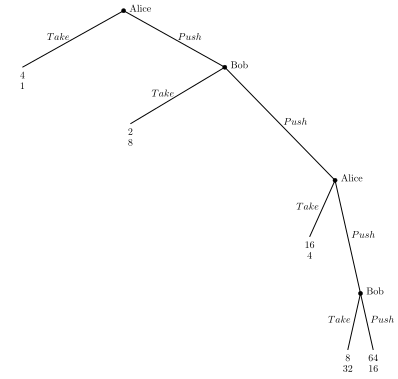

In [42]:
draw_tree("games/test.efg")

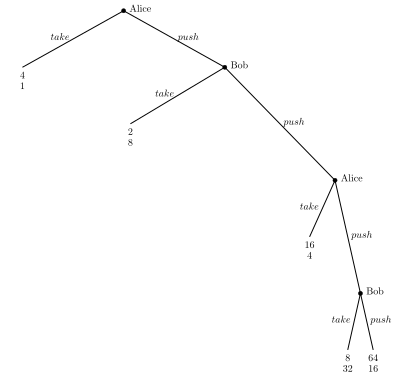

In [44]:
draw_tree("games/centipede.efg")